#  1. Install & Import Libraries

In [26]:

# Install external packages (like isodate) and import core libraries

!pip install isodate


# 2. Import Required Libraries

In [27]:


# Core libraries: pandas, numpy, matplotlib, seaborn → for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools: scikit-learn (train/test split, Random Forest, evaluation metrics)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Extra utilities
import isodate     # For parsing video duration strings (ISO 8601 → seconds)
import joblib      # For saving/loading trained models
import warnings    # To suppress warnings for cleaner output
warnings.filterwarnings('ignore')


# 3. Load Dataset #

In [28]:
#  Load Dataset #
# Reading the YouTube channel performance analytics CSV file into a pandas DataFrame.
# This will allow us to explore, clean, and analyze the data further.

data=pd.read_csv('/content/youtube_channel_real_performance_analytics.csv')


# 4. Preview Dataset #


In [29]:
# Using .head() to quickly view the first few records of the dataset.
# This helps verify that the data loaded correctly and gives an initial sense of its structure.
data.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [30]:
# Using .tail() to view the final few records of the dataset.
# This helps check the ending rows and confirm data consistency
data.tail()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
359,359,779.0,2024-08-25 00:00:00,10,25,8,2024,Sunday,0.806,4104.0,...,0.0,0.0,50.82,396.0,10018.0,1104.5703,16.0,8.063,97065.0,8.23
360,360,818.0,2024-09-01 00:00:00,7,1,9,2024,Sunday,1.050,3273.0,...,0.0,0.0,42.05,344.0,8298.0,793.6508,7.0,8.705,65912.0,9.36
361,361,2233.0,2024-09-16 00:00:00,15,16,9,2024,Monday,1.161,3605.0,...,0.0,0.0,31.48,703.0,8487.0,1657.8232,14.0,9.852,76517.0,8.28
362,362,391.0,2024-09-25 00:00:00,9,25,9,2024,Wednesday,0.547,2338.0,...,0.0,0.0,62.38,244.0,7060.0,479.5583,11.0,3.858,67091.0,8.29
363,363,1875.0,2024-10-18 00:00:00,23,18,10,2024,Friday,1.600,1791.0,...,0.0,0.0,40.26,755.0,3890.0,816.1554,-3.0,5.915,43431.0,6.67


In [31]:
# Using .info() to display column names, data types, and non-null counts.
# This helps identify missing values and understand the overall structure of the dataset.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [32]:
#Using .describe() to generate summary statistics (count, mean, std, min, quartiles, max)
data.describe()

,ID,Video Duration,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02,364.000000
mean,181.500000,664.239011,8.406593,15.807692,6.642857,2018.736264,0.112283,8934.711538,1.553734,1.059005,...,0.824176,0.008242,45.970989,285.612637,128800.101648,10058.965455,321.024725,8.852052,9.595286e+05,7.914615
std,105.221988,330.646183,15.371239,8.924004,3.421521,2.530629,0.179668,12967.843236,1.078549,0.728380,...,9.053369,0.090534,12.457470,116.595678,118209.844270,9516.160361,444.594763,13.414650,1.180519e+06,2.903383
min,0.000000,9.000000,0.000000,1.000000,1.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.050000,8.000000,2461.000000,12.697900,-3.000000,0.000000,3.222800e+04,0.620000
25%,90.750000,496.000000,3.000000,8.000000,4.000000,2017.000000,0.015000,349.500000,0.817750,0.522000,...,0.000000,0.000000,40.252500,233.750000,27160.500000,2759.404250,41.000000,0.443250,1.317082e+05,6.420000
50%,181.500000,613.000000,5.000000,16.000000,7.000000,2018.000000,0.050000,3564.000000,1.540500,1.155500,...,0.000000,0.000000,45.465000,286.500000,101950.500000,8102.962950,180.000000,4.285000,6.204065e+05,8.395000
75%,272.250000,786.500000,9.000000,23.000000,10.000000,2021.000000,0.143500,13579.250000,2.025250,1.458750,...,0.000000,0.000000,51.010000,344.250000,198169.500000,14084.498550,421.250000,11.476250,1.368464e+06,9.920000
max,363.000000,2311.000000,260.000000,31.000000,12.000000,2024.000000,1.600000,100566.000000,7.385000,6.295000,...,100.000000,1.000000,117.300000,776.000000,670990.000000,53794.658700,3728.000000,103.117000,1.270226e+07,27.660000


# 5. Feature Engineering – Time-Based Features #


In [33]:
# Convert to datetime format
data['Video Publish Time'] = pd.to_datetime(data['Video Publish Time'])

# Extract useful time-based features
data['Publish_Year'] = data['Video Publish Time'].dt.year
data['Publish_Month'] = data['Video Publish Time'].dt.month
data['Publish_Day'] = data['Video Publish Time'].dt.day
data['Publish_DayOfWeek'] = data['Video Publish Time'].dt.day_name()
data['Publish_Hour'] = data['Video Publish Time'].dt.hour

# Quick check
data[['Video Publish Time','Publish_Year','Publish_Month','Publish_Day','Publish_DayOfWeek','Publish_Hour']].head()


,Video Publish Time,Publish_Year,Publish_Month,Publish_Day,Publish_DayOfWeek,Publish_Hour
0,2016-06-02,2016,6,2,Thursday,0
1,2016-06-10,2016,6,10,Friday,0
2,2016-06-14,2016,6,14,Tuesday,0
3,2016-06-29,2016,6,29,Wednesday,0
4,2016-07-01,2016,7,1,Friday,0


In [34]:
# Creating a new metric 'Engagement_Quality' to measure how effective a video is at engaging viewers.
# Formula:
# (Likes + Shares) / Views → engagement rate # Multiplied by Average View Duration → adjusts for how long viewers stay engaged
# This feature combines interaction and watch time to better capture overall engagement quality.

data['Engagement_Quality'] = (
    (data['Likes'] + data['Shares']) / data['Views']
) * data['Average View Duration']




In [35]:
# Show the first few values
print(data[['Likes','Shares','Views','Average View Duration','Engagement_Quality']].head())


   Likes  Shares    Views  Average View Duration  Engagement_Quality
0  924.0    12.0  23531.0                   81.0            3.221963
1  322.0     5.0  11478.0                  156.0            4.444328
2  239.0     4.0   6153.0                   41.0            1.619210
3  220.0     7.0   4398.0                   14.0            0.722601
4  602.0     7.0  14659.0                   25.0            1.038611


# 6. Check for Missing Values #


In [36]:
print(data.isnull().sum())      # Check missing values



ID                    0
Video Duration        0
Video Publish Time    0
Days Since Publish    0
Day                   0
                     ..
Publish_Month         0
Publish_Day           0
Publish_DayOfWeek     0
Publish_Hour          0
Engagement_Quality    0
Length: 76, dtype: int64


# 7. Model Comparison – Random Forest vs Gradient Boosting #


Random Forest RMSE: 0.7331983002366211
Gradient Boosting RMSE: 0.37314287852721617


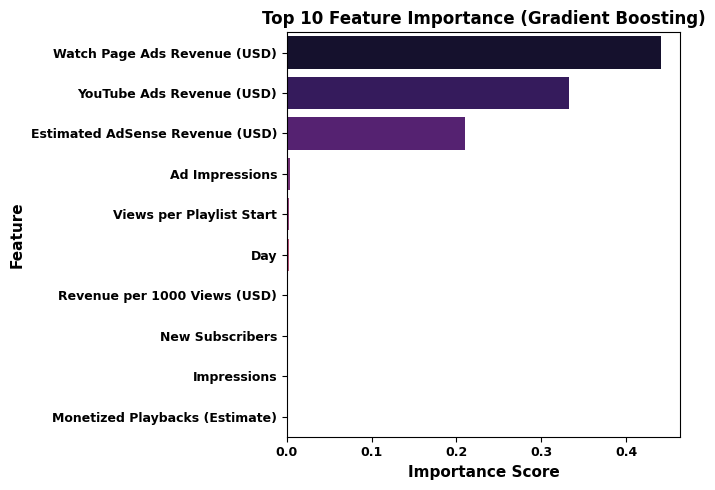

In [37]:
# =============================== #
# Model Comparison: Random Forest vs Gradient Boosting #
# In this section, I compare  two regression models:
# 1. Random Forest Regressor
# 2. Gradient Boosting Regressor



# Steps:
# - Define features (X) and target (y) from numeric columns
# - Split data into training and testing sets # - Train both models and generate predictions
# - Evaluate performance using RMSE (Root Mean Squared Error)
# - Print RMSE values for comparison


from sklearn.ensemble import GradientBoostingRegressor
numeric_df = data.select_dtypes(include='number')


# --- Features and Target ---
X = numeric_df.drop(columns=['Estimated Revenue (USD)'])
y = numeric_df['Estimated Revenue (USD)']

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# --- Gradient Boosting ---
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

# --- Compare Results ---
print("Random Forest RMSE:", rf_rmse)
print("Gradient Boosting RMSE:", gb_rmse)

# --- Feature Importance (Gradient Boosting) ---
gb_importances = gb_model.feature_importances_
gb_feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_importances
}).sort_values(by='Importance', ascending=False)


# - Extract and visualize feature importance from Gradient Boosting
# - Plot the Top 10 most important features using a bar chart (magma palette)

plt.figure(figsize=(7,5))  # smaller chart for screenshots
sns.barplot(x='Importance', y='Feature', data=gb_feat_importances.head(10), palette='magma')

# Make all text bold and black
plt.title('Top 10 Feature Importance (Gradient Boosting)', fontsize=12, fontweight='bold', color='black')
plt.xlabel('Importance Score', fontsize=11, fontweight='bold', color='black')
plt.ylabel('Feature', fontsize=11, fontweight='bold', color='black')

# Bold tick labels
plt.xticks(fontsize=9, fontweight='bold', color='black')
plt.yticks(fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


# Purpose:
# This comparison helps identify which model performs better and highlights
# the most influential features driving revenue prediction.


In [38]:
print(data.duplicated().sum())  # Check duplicates

0


# 8. Video Duration Distribution #


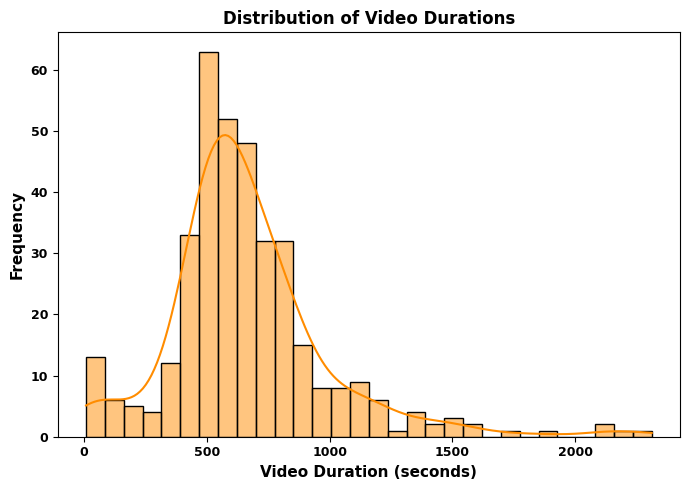

In [39]:
# Video Duration Distribution
# Plotting a histogram of video durations (in seconds).

#purpose:
# - Understand the spread and common ranges of video lengths
# - Identify whether most videos are short, medium, or long
# - Detect any skewness or unusual patterns in duration # # The KDE (density curve) is added to visualize the overall distribution trend.


plt.figure(figsize=(7,5))  # smaller chart for screenshots
sns.histplot(
    data['Video Duration'],
    bins=30,
    kde=True,
    color='darkorange'   # change chart color (example: dark orange)
)

# Make all text bold and black
plt.title('Distribution of Video Durations', fontsize=12, fontweight='bold', color='black')
plt.xlabel('Video Duration (seconds)', fontsize=11, fontweight='bold', color='black')
plt.ylabel('Frequency', fontsize=11, fontweight='bold', color='black')

# Bold tick labels
plt.xticks(fontsize=9, fontweight='bold', color='black')
plt.yticks(fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


# 9. Revenue Distribution #


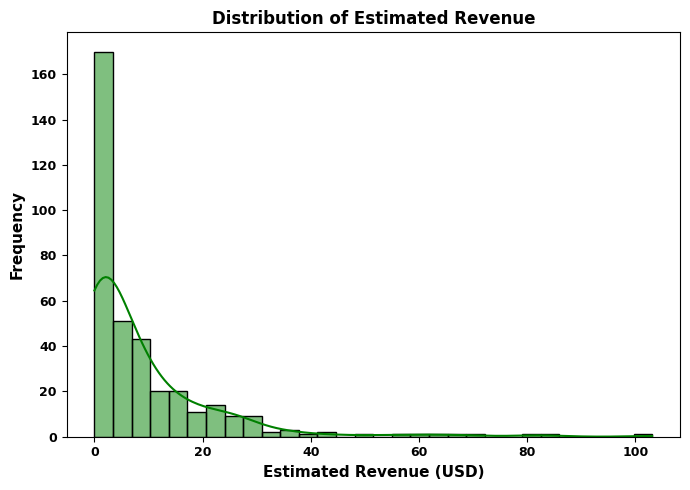

In [40]:
plt.figure(figsize=(7,5))  # smaller chart for screenshots
sns.histplot(
    data['Estimated Revenue (USD)'],
    bins=30,
    kde=True,
    color='green'   # set chart color to green
)

# Make all text bold and black
plt.title('Distribution of Estimated Revenue', fontsize=12, fontweight='bold', color='black')
plt.xlabel('Estimated Revenue (USD)', fontsize=11, fontweight='bold', color='black')
plt.ylabel('Frequency', fontsize=11, fontweight='bold', color='black')

# Bold tick labels
plt.xticks(fontsize=9, fontweight='bold', color='black')
plt.yticks(fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


# 10. Correlation Heatmap #


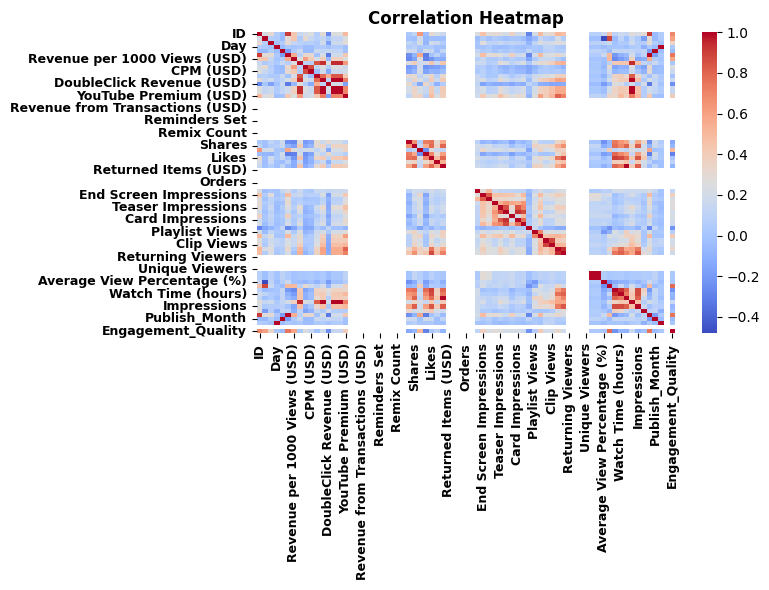

In [41]:
plt.figure(figsize=(8,6))  # smaller chart for screenshots
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

# Make all text bold and black
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold', color='black')

# Bold tick labels
plt.xticks(fontsize=9, fontweight='bold', color='black')
plt.yticks(fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


# 11. Feature Importance – Random Forest #


RMSE: 0.7331983002366211
                            Feature  Importance
13        YouTube Ads Revenue (USD)    0.373194
14     Watch Page Ads Revenue (USD)    0.334634
11  Estimated AdSense Revenue (USD)    0.234944
7    Monetized Playbacks (Estimate)    0.024467
10                   Ad Impressions    0.004383
..                              ...         ...
54                Returning Viewers    0.000000
57                   Unique Viewers    0.000000
56           Average Views per User    0.000000
59                 Feed Impressions    0.000000
70                     Publish_Hour    0.000000

[72 rows x 2 columns]


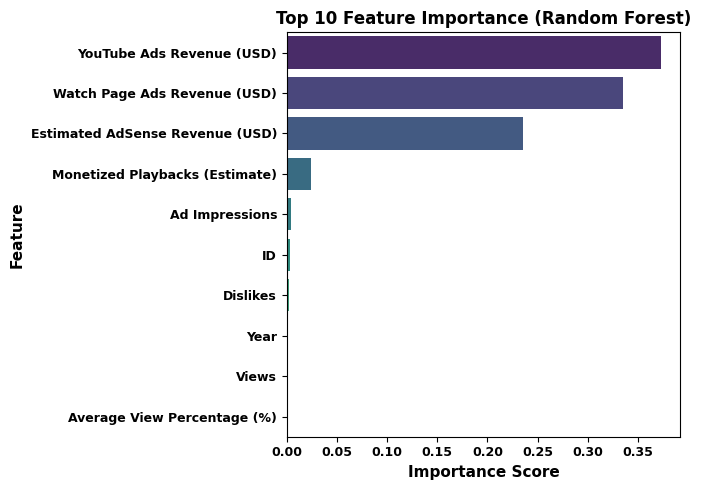

In [42]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# --- Features and Target ---
X = numeric_df.drop(columns=['Estimated Revenue (USD)'])
y = numeric_df['Estimated Revenue (USD)']

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Model Training ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# --- Feature Importance ---
importances = model.feature_importances_
feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importances)

# --- Select Top 10 Features ---
top_features = feat_importances.head(10)

# --- Visualize Top 10 Feature Importance ---
# Bar chart showing most influential features in predicting revenue
# --- Visualize Top 10 Feature Importance ---
plt.figure(figsize=(7,5))  # slightly smaller chart for screenshots
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

# Make all text bold and black
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=12, fontweight='bold', color='black')
plt.xlabel('Importance Score', fontsize=11, fontweight='bold', color='black')
plt.ylabel('Feature', fontsize=11, fontweight='bold', color='black')

# Bold tick labels
plt.xticks(fontsize=9, fontweight='bold', color='black')
plt.yticks(fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()




# 12. SHAP Analysis – Model Interpretability #


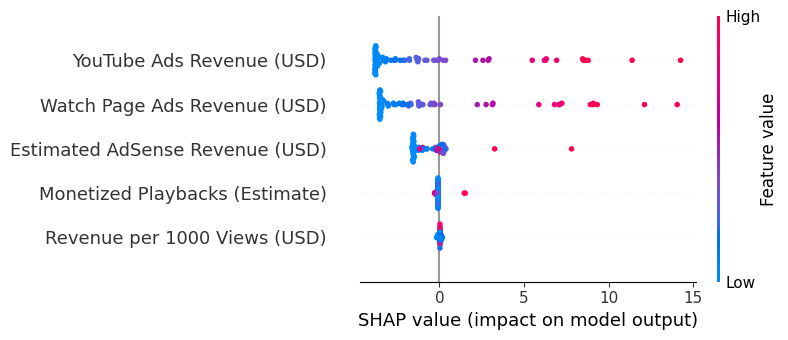

In [43]:
import shap

# Explain model predictions using SHAP
explainer = shap.TreeExplainer(rf_model)  # or gb_model
shap_values = explainer.shap_values(X_test)

# Show only top 5 features
shap.summary_plot(shap_values, X_test, max_display=5)


# 13. SHAP Dependence Plot – Views vs Revenue #


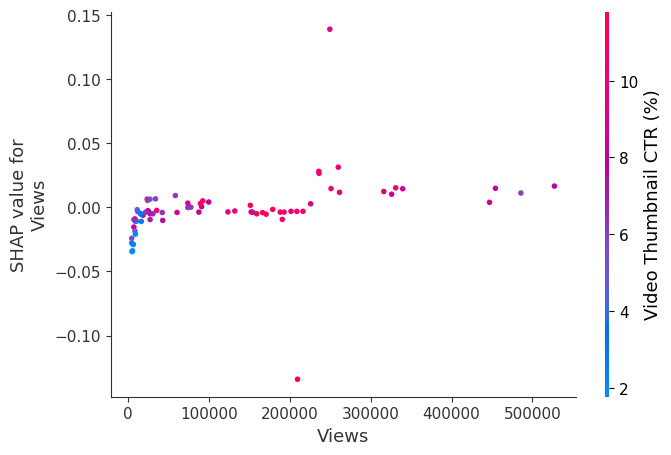

In [44]:

# Dependence plot (relationship of one feature with revenue)
shap.dependence_plot("Views", shap_values, X_test)

# 14. Partial Dependence Plots – Views & Engagement Quality #


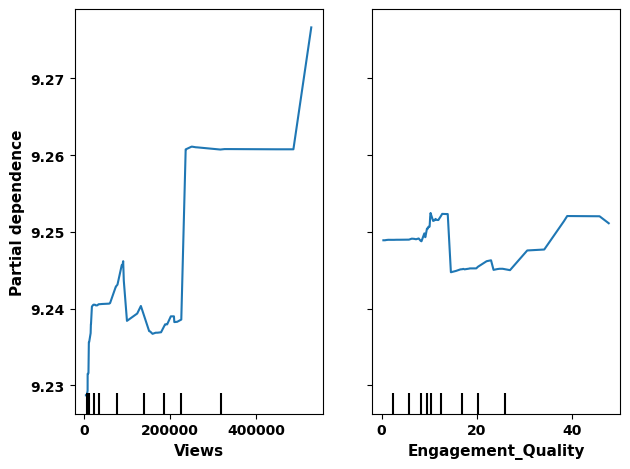

In [45]:
from sklearn.inspection import PartialDependenceDisplay

# Plot PDP for top features
fig, ax = plt.subplots()
display = PartialDependenceDisplay.from_estimator(
    rf_model, X_test, ["Views", "Engagement_Quality"], ax=ax
)

# Apply styling to all subplots
for axes in np.ravel(display.axes_):
    axes.set_title(axes.get_title(), fontsize=12, fontweight='bold', color='black')
    axes.set_xlabel(axes.get_xlabel(), fontsize=11, fontweight='bold', color='black')
    axes.set_ylabel(axes.get_ylabel(), fontsize=11, fontweight='bold', color='black')

    # Make tick numbers black + bold
    for label in axes.get_xticklabels():
        label.set_color('black')
        label.set_fontweight('bold')
    for label in axes.get_yticklabels():
        label.set_color('black')
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()




# 15. Save Feature Importance Chart as PNG #


In [46]:
# Save cleaned dataset
data.to_csv("youtube_clean.csv", index=False)

# Save feature importance table
feat_importances.to_csv("feature_importance.csv", index=False)


# 15. Export Feature Importance Chart as PNG #


In [47]:
# Save the current matplotlib figure as a PNG image
# dpi=300 ensures high-resolution (print-quality) output
# bbox_inches='tight' trims extra whitespace around the plot
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

# 16. Download Cleaned Dataset (youtube_clean.csv) #


In [48]:
from google.colab import files

# Download the cleaned dataset (youtube_clean.csv) to your local machine
files.download("youtube_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 17. Download Feature Importance Table (feature_importance.csv) #


In [49]:
# Download the feature importance table (feature_importance.csv) to your local machine
files.download("feature_importance.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 18. Download Feature Importance Plot (feature_importance.png) #


In [50]:
# Download the saved feature importance plot (feature_importance.png) to your local machine
files.download("feature_importance.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>